# WRF Tropical Cyclone: Plotting a Map with Brightness Temperature (Tb) from OLR

This notebook does one thing:

1. Read **OLR** from a WRF `wrfout` file  
2. Convert OLR → **brightness temperature** **Tb** (simple blackbody approximation + standard IR conversion)  
3. Read an **observational Tb** dataset on the WRF grid  
4. Plot **WRF Tb** and **Observed Tb** side-by-side for one time step

Keep it simple: change only the paths in the next cell.


In [1]:
!which python

/cluster/software/stacks/2024-05/spack/opt/spack/linux-ubuntu22.04-x86_64_v3/gcc-13.2.0/python-3.11.6-m4n2ny4dwaqmeobuqquo3gpyw2bct67i/bin/python


In [2]:
user = "twenke"

In [3]:
# === USER SETTINGS (edit these) ===
wrfout_pattern = f"/cluster/home/{user}/wcm/wrf-model/wrf-output/era5_default/wrfout_d01_*"        # e.g. "/cluster/work/.../wrfout_d01_*"
ocean_pattern = f"/cluster/home/{user}/wcm/wrf-model/wrf-output/slab_ocean/wrfout_d01_*"
obs_tb_file    = f"/cluster/home/{user}/wcm/wrf-model/OBS/Tb_on_wrf.nc"        # e.g. "/cluster/home/.../Tb_on_wrf.nc"

# Choose which time index to plot (0 = first time in file list)
t_index = 30

# Optional: if your observational file has a different time naming, set it here
obs_time_dim_name = "Time"   # in our course file this is "Time"

In [4]:
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Cartopy is used only to put the data on a map projection.
import cartopy.crs as ccrs

In [5]:
# --- Load WRF output (can be one file or many files) ---
wrf_files = sorted(glob.glob(wrfout_pattern))
if len(wrf_files) == 0:
    raise FileNotFoundError(f"No WRF files found for pattern: {wrfout_pattern}")

# For teaching simplicity: open all files as one dataset along Time.
ds_wrf = xr.open_mfdataset(wrf_files, combine="nested", concat_dim="Time")

# Latitude/longitude (WRF uses XLAT/XLONG; take the first Time slice)
lat = ds_wrf["XLAT"].isel(Time=0)
lon = ds_wrf["XLONG"].isel(Time=0)

ds_wrf

<xarray.Dataset> Size: 3GB
Dimensions:                (Time: 65, south_north: 119, west_east: 90,
                            bottom_top: 44, bottom_top_stag: 45,
                            soil_layers_stag: 4, west_east_stag: 91,
                            south_north_stag: 120, seed_dim_stag: 8)
Coordinates:
    XTIME                  (Time) datetime64[ns] 520B dask.array<chunksize=(1,), meta=np.ndarray>
    XLAT                   (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 119, 90), meta=np.ndarray>
    XLONG                  (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 119, 90), meta=np.ndarray>
    XLAT_V                 (Time, south_north_stag, west_east) float32 3MB dask.array<chunksize=(1, 120, 90), meta=np.ndarray>
    XLONG_V                (Time, south_north_stag, west_east) float32 3MB dask.array<chunksize=(1, 120, 90), meta=np.ndarray>
    XLAT_U                 (Time, south_north, west_east_stag) float32 3MB dask.array<chunksize=(1, 119, 91), meta=np.ndarray>
    XLONG_U                (Time, south_north, west_east_stag) float32 3MB dask.array<chunksize=(1, 119, 91), meta=np.ndarray>
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
                                bottom_top_stag, soil_layers_stag,
                                west_east_stag, south_north_stag, seed_dim_stag
Data variables: (12/207)
    Times                  (Time) |S19 1kB dask.array<chunksize=(1,), meta=np.ndarray>
    LU_INDEX               (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 119, 90), meta=np.ndarray>
    ZNU                    (Time, bottom_top) float32 11kB dask.array<chunksize=(1, 44), meta=np.ndarray>
    ZNW                    (Time, bottom_top_stag) float32 12kB dask.array<chunksize=(1, 45), meta=np.ndarray>
    ZS                     (Time, soil_layers_stag) float32 1kB dask.array<chunksize=(1, 4), meta=np.ndarray>
    DZS                    (Time, soil_layers_stag) float32 1kB dask.array<chunksize=(1, 4), meta=np.ndarray>
    ...                     ...
    PCB                    (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 119, 90), meta=np.ndarray>
    PC                     (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 119, 90), meta=np.ndarray>
    LANDMASK               (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 119, 90), meta=np.ndarray>
    LAKEMASK               (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 119, 90), meta=np.ndarray>
    SST                    (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 119, 90), meta=np.ndarray>
    SST_INPUT              (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 119, 90), meta=np.ndarray>
Attributes: (12/136)
    TITLE:                            OUTPUT FROM WRF V4.6.0 MODEL
    START_DATE:                      2016-10-01_00:00:00
    SIMULATION_START_DATE:           2016-10-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        91
    SOUTH-NORTH_GRID_DIMENSION:      120
    BOTTOM-TOP_GRID_DIMENSION:       45
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2

In [6]:
var = "SST"

In [7]:
# Outgoing Longwave Radiation (W/m^2)
if var not in ds_wrf:
    raise KeyError("Variable 'OLR' not found in wrfout. Check your output variables.")
olr = ds_wrf[var].isel(Time=t_index)

ds_wrf

<xarray.Dataset> Size: 3GB
Dimensions:                (Time: 65, south_north: 119, west_east: 90,
                            bottom_top: 44, bottom_top_stag: 45,
                            soil_layers_stag: 4, west_east_stag: 91,
                            south_north_stag: 120, seed_dim_stag: 8)
Coordinates:
    XTIME                  (Time) datetime64[ns] 520B dask.array<chunksize=(1,), meta=np.ndarray>
    XLAT                   (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 119, 90), meta=np.ndarray>
    XLONG                  (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 119, 90), meta=np.ndarray>
    XLAT_V                 (Time, south_north_stag, west_east) float32 3MB dask.array<chunksize=(1, 120, 90), meta=np.ndarray>
    XLONG_V                (Time, south_north_stag, west_east) float32 3MB dask.array<chunksize=(1, 120, 90), meta=np.ndarray>
    XLAT_U                 (Time, south_north, west_east_stag) float32 3MB dask.array<chunksize=(1, 119, 91), meta=np.ndarray>
    XLONG_U                (Time, south_north, west_east_stag) float32 3MB dask.array<chunksize=(1, 119, 91), meta=np.ndarray>
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
                                bottom_top_stag, soil_layers_stag,
                                west_east_stag, south_north_stag, seed_dim_stag
Data variables: (12/207)
    Times                  (Time) |S19 1kB dask.array<chunksize=(1,), meta=np.ndarray>
    LU_INDEX               (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 119, 90), meta=np.ndarray>
    ZNU                    (Time, bottom_top) float32 11kB dask.array<chunksize=(1, 44), meta=np.ndarray>
    ZNW                    (Time, bottom_top_stag) float32 12kB dask.array<chunksize=(1, 45), meta=np.ndarray>
    ZS                     (Time, soil_layers_stag) float32 1kB dask.array<chunksize=(1, 4), meta=np.ndarray>
    DZS                    (Time, soil_layers_stag) float32 1kB dask.array<chunksize=(1, 4), meta=np.ndarray>
    ...                     ...
    PCB                    (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 119, 90), meta=np.ndarray>
    PC                     (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 119, 90), meta=np.ndarray>
    LANDMASK               (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 119, 90), meta=np.ndarray>
    LAKEMASK               (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 119, 90), meta=np.ndarray>
    SST                    (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 119, 90), meta=np.ndarray>
    SST_INPUT              (Time, south_north, west_east) float32 3MB dask.array<chunksize=(1, 119, 90), meta=np.ndarray>
Attributes: (12/136)
    TITLE:                            OUTPUT FROM WRF V4.6.0 MODEL
    START_DATE:                      2016-10-01_00:00:00
    SIMULATION_START_DATE:           2016-10-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        91
    SOUTH-NORTH_GRID_DIMENSION:      120
    BOTTOM-TOP_GRID_DIMENSION:       45
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2

[Here](https://link.springer.com/article/10.1007/s11434-011-4686-6) is an example of how outgoing longwave radiation (OLR) is estimated from satellite measured infra-red (IR) Tb. We follow the calculation of this paper to estimate Tb from the modelled OLR.

In [11]:
# --- Load observational Tb (already preprocessed onto the WRF grid) ---
ds_obs = xr.open_dataset(obs_tb_file)

# If needed, rename the time dimension to match the WRF dataset
if "time" in ds_obs.dims and obs_time_dim_name not in ds_obs.dims:
    ds_obs = ds_obs.rename({"time": obs_time_dim_name})

# For simplicity, assume the file contains exactly one Tb-like variable
if var not in ds_obs.data_vars:
    first_var = list(ds_obs.data_vars)[0]
    ds_obs = ds_obs.rename_vars({first_var: var})

Tb_obs = ds_obs[var].isel({obs_time_dim_name: t_index})

ds_obs

<xarray.Dataset> Size: 3MB
Dimensions:  (Time: 65, south_north: 119, west_east: 90)
Coordinates:
  * Time     (Time) datetime64[ns] 520B 2016-10-01 ... 2016-10-09
    XLAT     (south_north, west_east) float32 43kB ...
    XLONG    (south_north, west_east) float32 43kB ...
Dimensions without coordinates: south_north, west_east
Data variables:
    SST      (Time, south_north, west_east) float32 3MB ...

/scratch/tmp.63754665.twenke/ipykernel_2502098/3860002308.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


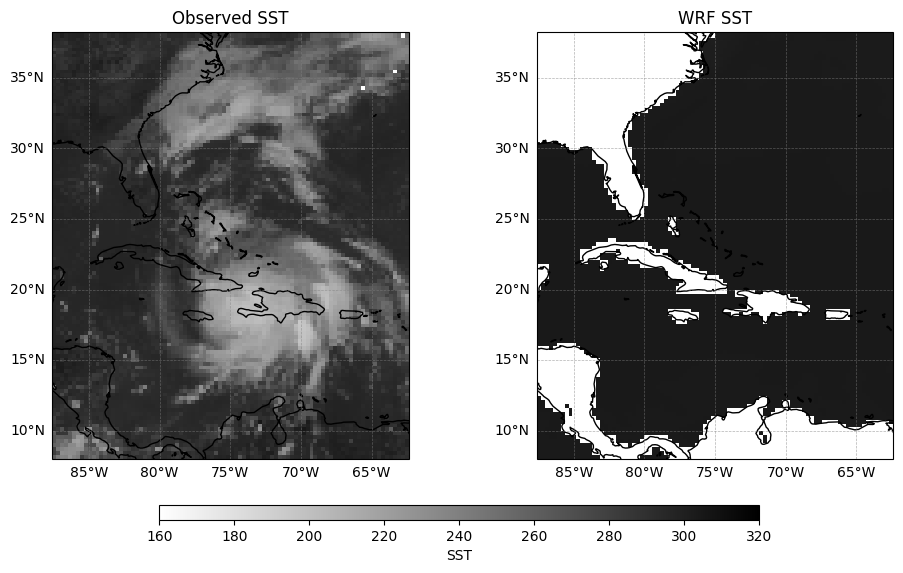

In [12]:
# --- Plot: Observed vs WRF Tb side-by-side ---
vmin, vmax = 160, 320  # K (simple fixed limits)

fig = plt.figure(figsize=(10, 5))

# Left: Observations
ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1.set_title(f"Observed {var}")
im1 = ax1.pcolormesh(lon, lat, Tb_obs, transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax, cmap="gray_r")
ax1.coastlines()
gl = ax1.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.6,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False

# Right: WRF
ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())
ax2.set_title(f"WRF {var}")
im2 = ax2.pcolormesh(lon, lat, Tb_wrf, transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax, cmap="gray_r")
ax2.coastlines()
gl = ax2.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.6,
    linestyle="--"
)

gl.top_labels = False
gl.right_labels = False

# One shared colorbar
cax = fig.add_axes([0.20, -0.05, 0.6, 0.03])
cbar = fig.colorbar(im2, cax=cax,
                    orientation="horizontal")   # distance from plot
cbar.set_label(var)

plt.tight_layout()
plt.show()